In [1]:
import torch 
import torch.optim as optim 
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torchvision import transforms, models, datasets 

In [2]:
train_40X = "Final-40X\\train" 
val_40X = "Final-40X\\val"

train_100X = "Final-100X\\train" 
val_100X = "Final-100X\\val"

train_200X = "Final-200X\\train"
val_200X = "Final-200X\\val" 

train_400X = "Final-400X\\train"
val_400X = "Final-400X\\val" 

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
model = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
device = torch.device("cuda")


# Training on 40X Dataset without preprocessing

In [6]:
train_data = datasets.ImageFolder(train_40X, transform=transform)
val_data   = datasets.ImageFolder(val_40X, transform=transform)


In [7]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)


In [8]:
for param in model.features.parameters():
    param.requires_grad = False

In [9]:
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [10]:
model = model.to(device)

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [12]:
def train_model(model, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                outputs = torch.sigmoid(model(imgs))
                preds.extend((outputs.cpu().numpy() > 0.5).astype(int))
                true.extend(labels.numpy())

        acc = accuracy_score(true, preds)
        f1  = f1_score(true, preds)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")



In [13]:
train_model(model, epochs=15)

Epoch 1/15 | Loss: 0.6302 | Acc: 0.7732 | F1: 0.7759
Epoch 2/15 | Loss: 0.5510 | Acc: 0.8317 | F1: 0.8406
Epoch 3/15 | Loss: 0.4961 | Acc: 0.8488 | F1: 0.8558
Epoch 4/15 | Loss: 0.4501 | Acc: 0.8683 | F1: 0.8708
Epoch 5/15 | Loss: 0.4237 | Acc: 0.8805 | F1: 0.8874
Epoch 6/15 | Loss: 0.3971 | Acc: 0.8902 | F1: 0.8941
Epoch 7/15 | Loss: 0.3743 | Acc: 0.8902 | F1: 0.8946
Epoch 8/15 | Loss: 0.3536 | Acc: 0.8951 | F1: 0.8998
Epoch 9/15 | Loss: 0.3411 | Acc: 0.9049 | F1: 0.9078
Epoch 10/15 | Loss: 0.3334 | Acc: 0.9073 | F1: 0.9104
Epoch 11/15 | Loss: 0.3226 | Acc: 0.9024 | F1: 0.9038
Epoch 12/15 | Loss: 0.3096 | Acc: 0.9049 | F1: 0.9060
Epoch 13/15 | Loss: 0.3060 | Acc: 0.9049 | F1: 0.9078
Epoch 14/15 | Loss: 0.2949 | Acc: 0.9073 | F1: 0.9100
Epoch 15/15 | Loss: 0.2892 | Acc: 0.9073 | F1: 0.9095


In [14]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)


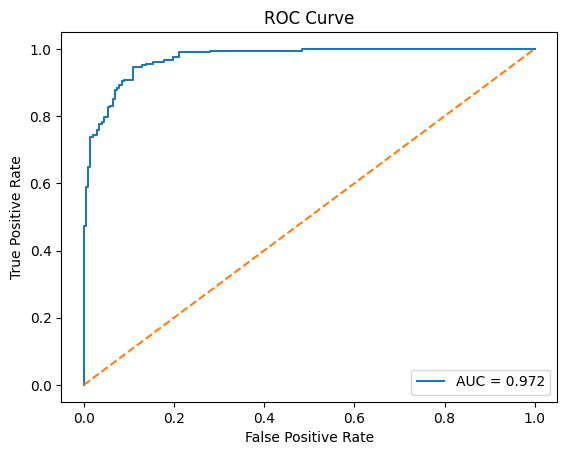

In [15]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


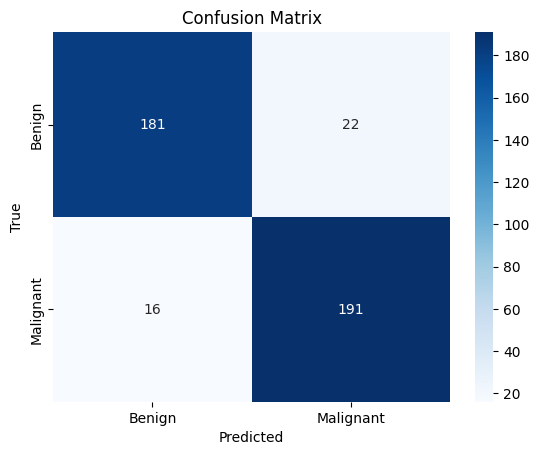

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [17]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.92      0.89      0.91       203
   Malignant       0.90      0.92      0.91       207

    accuracy                           0.91       410
   macro avg       0.91      0.91      0.91       410
weighted avg       0.91      0.91      0.91       410



In [18]:
torch.save(model.state_dict(), "Densenet40X.pth")
print("Model saved as Densenet40X.pth")


Model saved as Densenet40X.pth


# Training on 100X Dataset without preprocessing

In [28]:
train_data2 = datasets.ImageFolder(train_100X, transform=transform)
val_data2  = datasets.ImageFolder(val_100X, transform=transform)


In [29]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


In [30]:
fresh_model = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
for param in fresh_model.features.parameters():
    param.requires_grad = False

In [37]:
num_features = fresh_model.classifier.in_features
fresh_model.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [38]:
fresh_model = fresh_model.to(device)

In [39]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fresh_model.parameters(), lr=1e-4)

In [40]:
train_model(fresh_model, epochs=15)

Epoch 1/15 | Loss: 0.6418 | Acc: 0.7221 | F1: 0.7194
Epoch 2/15 | Loss: 0.5703 | Acc: 0.8385 | F1: 0.8440
Epoch 3/15 | Loss: 0.5181 | Acc: 0.8646 | F1: 0.8707
Epoch 4/15 | Loss: 0.4790 | Acc: 0.8789 | F1: 0.8854
Epoch 5/15 | Loss: 0.4455 | Acc: 0.8907 | F1: 0.8973
Epoch 6/15 | Loss: 0.4189 | Acc: 0.8955 | F1: 0.9013
Epoch 7/15 | Loss: 0.3933 | Acc: 0.8931 | F1: 0.8993
Epoch 8/15 | Loss: 0.3821 | Acc: 0.9097 | F1: 0.9136
Epoch 9/15 | Loss: 0.3602 | Acc: 0.9026 | F1: 0.9079
Epoch 10/15 | Loss: 0.3486 | Acc: 0.9145 | F1: 0.9193
Epoch 11/15 | Loss: 0.3394 | Acc: 0.9026 | F1: 0.9095
Epoch 12/15 | Loss: 0.3348 | Acc: 0.9169 | F1: 0.9217
Epoch 13/15 | Loss: 0.3119 | Acc: 0.9192 | F1: 0.9217
Epoch 14/15 | Loss: 0.3064 | Acc: 0.9216 | F1: 0.9255
Epoch 15/15 | Loss: 0.3025 | Acc: 0.9216 | F1: 0.9255


In [41]:
torch.save(fresh_model.state_dict(), "Densenet100X.pth")
print("Model saved as Densenet100X.pth")

Model saved as Densenet100X.pth


In [42]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
fresh_model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(fresh_model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)


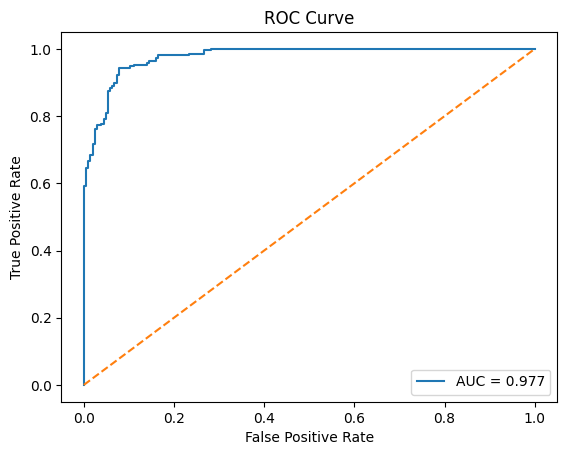

In [43]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


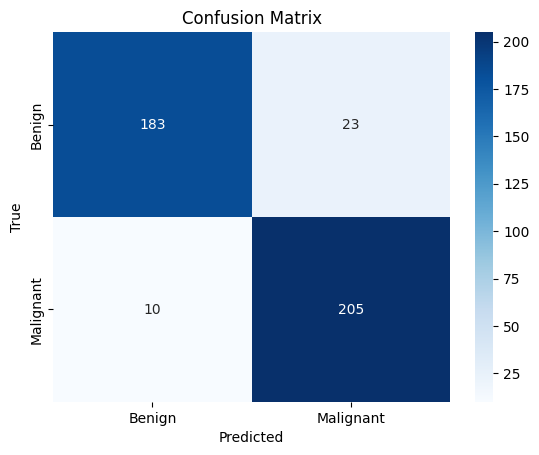

In [44]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [45]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.89      0.92       206
   Malignant       0.90      0.95      0.93       215

    accuracy                           0.92       421
   macro avg       0.92      0.92      0.92       421
weighted avg       0.92      0.92      0.92       421



# Training on 200X Dataset

In [52]:
train_data3 = datasets.ImageFolder(train_200X, transform=transform)
val_data3  = datasets.ImageFolder(val_200X, transform=transform)


In [53]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


In [54]:
fresh_model2 = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [55]:
for param in fresh_model2.features.parameters():
    param.requires_grad = False

In [56]:
num_features = fresh_model2.classifier.in_features
fresh_model2.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [57]:
fresh_model2 = fresh_model2.to(device)

In [58]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fresh_model2.parameters(), lr=1e-4)

In [59]:
train_model(fresh_model2, epochs=15)

Epoch 1/15 | Loss: 0.6494 | Acc: 0.7221 | F1: 0.7310
Epoch 2/15 | Loss: 0.5752 | Acc: 0.7910 | F1: 0.8247
Epoch 2/15 | Loss: 0.5752 | Acc: 0.7910 | F1: 0.8247
Epoch 3/15 | Loss: 0.5238 | Acc: 0.8361 | F1: 0.8470
Epoch 3/15 | Loss: 0.5238 | Acc: 0.8361 | F1: 0.8470
Epoch 4/15 | Loss: 0.4809 | Acc: 0.8670 | F1: 0.8750
Epoch 4/15 | Loss: 0.4809 | Acc: 0.8670 | F1: 0.8750
Epoch 5/15 | Loss: 0.4475 | Acc: 0.8812 | F1: 0.8889
Epoch 5/15 | Loss: 0.4475 | Acc: 0.8812 | F1: 0.8889
Epoch 6/15 | Loss: 0.4185 | Acc: 0.8955 | F1: 0.9022
Epoch 6/15 | Loss: 0.4185 | Acc: 0.8955 | F1: 0.9022
Epoch 7/15 | Loss: 0.4048 | Acc: 0.9026 | F1: 0.9079
Epoch 7/15 | Loss: 0.4048 | Acc: 0.9026 | F1: 0.9079
Epoch 8/15 | Loss: 0.3801 | Acc: 0.9074 | F1: 0.9120
Epoch 8/15 | Loss: 0.3801 | Acc: 0.9074 | F1: 0.9120
Epoch 9/15 | Loss: 0.3623 | Acc: 0.9097 | F1: 0.9148
Epoch 9/15 | Loss: 0.3623 | Acc: 0.9097 | F1: 0.9148
Epoch 10/15 | Loss: 0.3448 | Acc: 0.9192 | F1: 0.9227
Epoch 10/15 | Loss: 0.3448 | Acc: 0.9192 | F1

In [60]:
torch.save(fresh_model2.state_dict(), "Densenet200X.pth")
print("Model saved as Densenet200X.pth")

Model saved as Densenet200X.pth


In [61]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
fresh_model2.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(fresh_model2(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)



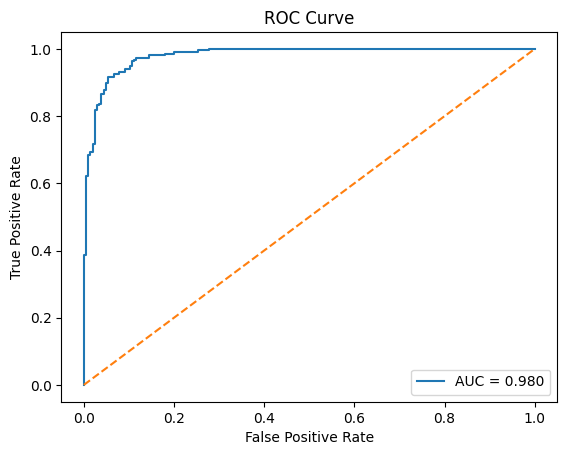

In [62]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


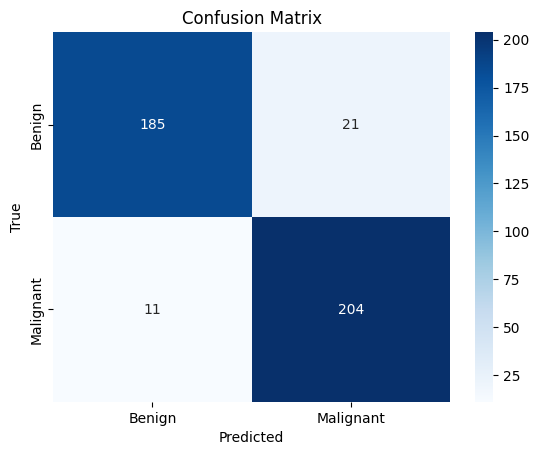

In [63]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [64]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.94      0.90      0.92       206
   Malignant       0.91      0.95      0.93       215

    accuracy                           0.92       421
   macro avg       0.93      0.92      0.92       421
weighted avg       0.92      0.92      0.92       421



# Training on 400X Dataset

In [65]:
train_data4 = datasets.ImageFolder(train_400X, transform=transform)
val_data4  = datasets.ImageFolder(val_400X, transform=transform)


In [66]:
train_loader = DataLoader(train_data4, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data4, batch_size=32, shuffle=False)


In [67]:
fresh_model3 = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [68]:
for param in model.features.parameters():
    param.requires_grad = False

In [69]:
num_features = fresh_model3.classifier.in_features
fresh_model3.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [70]:
fresh_model3 = fresh_model3.to(device)

In [71]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fresh_model3.parameters(), lr=1e-4)

In [72]:
train_model(fresh_model, epochs=15)

Epoch 1/15 | Loss: 0.3474 | Acc: 0.8883 | F1: 0.8894
Epoch 2/15 | Loss: 0.3517 | Acc: 0.8782 | F1: 0.8835
Epoch 2/15 | Loss: 0.3517 | Acc: 0.8782 | F1: 0.8835
Epoch 3/15 | Loss: 0.3404 | Acc: 0.8883 | F1: 0.8911
Epoch 3/15 | Loss: 0.3404 | Acc: 0.8883 | F1: 0.8911
Epoch 4/15 | Loss: 0.3411 | Acc: 0.8807 | F1: 0.8834
Epoch 4/15 | Loss: 0.3411 | Acc: 0.8807 | F1: 0.8834
Epoch 5/15 | Loss: 0.3456 | Acc: 0.8883 | F1: 0.8889
Epoch 5/15 | Loss: 0.3456 | Acc: 0.8883 | F1: 0.8889
Epoch 6/15 | Loss: 0.3423 | Acc: 0.8756 | F1: 0.8814
Epoch 6/15 | Loss: 0.3423 | Acc: 0.8756 | F1: 0.8814
Epoch 7/15 | Loss: 0.3478 | Acc: 0.8909 | F1: 0.8917
Epoch 7/15 | Loss: 0.3478 | Acc: 0.8909 | F1: 0.8917
Epoch 8/15 | Loss: 0.3412 | Acc: 0.8807 | F1: 0.8828
Epoch 8/15 | Loss: 0.3412 | Acc: 0.8807 | F1: 0.8828
Epoch 9/15 | Loss: 0.3396 | Acc: 0.8832 | F1: 0.8873
Epoch 9/15 | Loss: 0.3396 | Acc: 0.8832 | F1: 0.8873
Epoch 10/15 | Loss: 0.3474 | Acc: 0.8832 | F1: 0.8861
Epoch 10/15 | Loss: 0.3474 | Acc: 0.8832 | F1

In [77]:
torch.save(fresh_model3.state_dict(), "Densenet400X.pth")
print("Model saved as Densenet400X.pth")

Model saved as Densenet400X.pth


In [73]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
fresh_model3.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(fresh_model3(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)



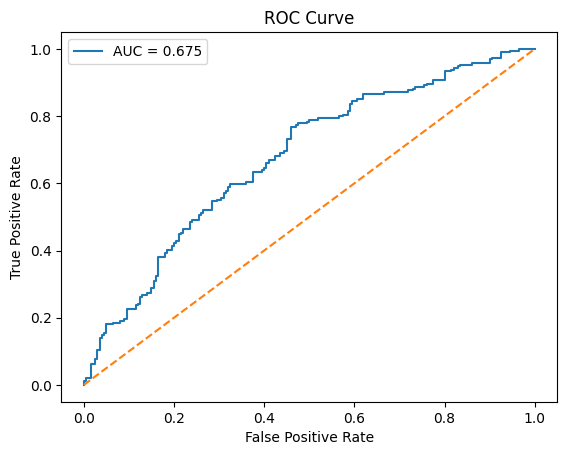

In [74]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


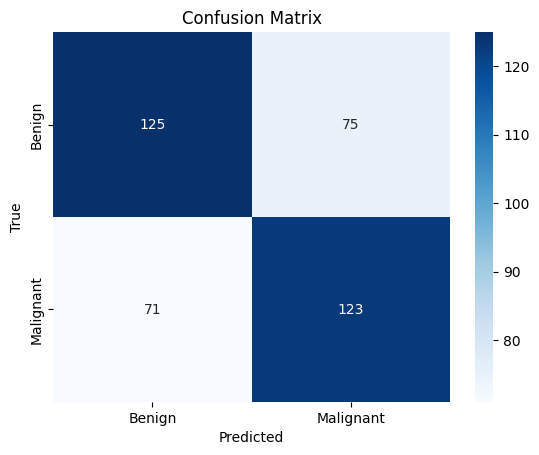

In [75]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [76]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.64      0.62      0.63       200
   Malignant       0.62      0.63      0.63       194

    accuracy                           0.63       394
   macro avg       0.63      0.63      0.63       394
weighted avg       0.63      0.63      0.63       394

